# 04 — Random Forest Hyperparameter Tuning

## Objective
To optimize RF hyperparameters using GridSearchCV.


In [12]:
import pandas as pd

data = pd.read_csv(
    "data/sp500_2015_2024_clean_tuning.csv",
    parse_dates=["Date"],
    index_col="Date"
)

print(data.shape)
print(data.head())

(1965, 14)
                  Close         High          Low         Open      Volume  \
Date                                                                         
2017-03-09  2364.870117  2369.080078  2354.540039  2363.489990  3718450000   
2017-03-10  2372.600098  2376.860107  2363.040039  2372.520020  3434400000   
2017-03-13  2373.469971  2374.419922  2368.520020  2371.560059  3166650000   
2017-03-14  2365.449951  2368.550049  2358.179932  2368.550049  3173760000   
2017-03-15  2385.260010  2390.010010  2368.939941  2370.340088  3909490000   

             Returns         MA20         MA50   Close_lag1   Close_lag5  \
Date                                                                       
2017-03-09  0.000800  2358.136011  2308.201196  2362.979980  2381.919922   
2017-03-10  0.003269  2361.372510  2310.275601  2364.870117  2383.120117   
2017-03-13  0.000367  2364.241003  2312.746602  2372.600098  2375.310059   
2017-03-14 -0.003379  2366.101001  2315.070400  2373.469971  2

In [13]:
feature_cols = ["Close", "Returns", "MA10", "MA20", "MA50", "MA100", "Close_lag1", "Close_lag5","Volume", "Vol20"]

from sklearn.model_selection import train_test_split

X=data[feature_cols]
y=data["Close_tomorrow"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

Train shape: (1572, 10)
Test shape : (393, 10)


In [14]:
from sklearn.model_selection import TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits = 5)

## Hyperparameter Grid


In [15]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

rf = RandomForestRegressor(random_state = 42, n_jobs = -1)

param_grid = {
    "n_estimators" : [100, 200, 300],
    "max_depth" : [None, 5, 10],
    "min_samples_leaf" : [1, 3, 5],
}



## Cross-Validation


In [16]:
grid = GridSearchCV(
    estimator = rf,
    param_grid = param_grid,
    cv = tscv,
    scoring = "neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1)

grid.fit(X, y)

Fitting 5 folds for each of 27 candidates, totalling 135 fits


GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [None, 5, 10],
                         'min_samples_leaf': [1, 3, 5],
                         'n_estimators': [100, 200, 300]},
             scoring='neg_root_mean_squared_error', verbose=1)

## Optimized Model


### Key Takeaways
- Tuning improves robustness.


In [17]:
print("Best param :", grid.best_params_)
print("Best CV RMSE :", -grid.best_score_)

best_rf = grid.best_estimator_

Best param : {'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 200}
Best CV RMSE : 355.51434694491263


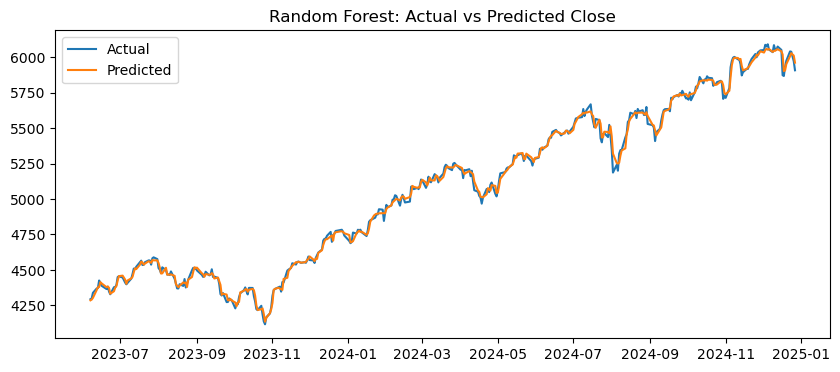

In [18]:
import matplotlib.pyplot as plt
y_pred = best_rf.predict(X_test)
test_dates = y_test.index

plt.figure(figsize=(10, 4))
plt.plot(test_dates, y_test, label = "Actual")
plt.plot(test_dates, y_pred, label = "Predicted")
plt.legend()
plt.title("Random Forest: Actual vs Predicted Close")
plt.show()

In [19]:
import numpy as np
actual_dir = np.sign(y_test.values - X_test["Close"].values)
pred_dir = np.sign(y_pred - X_test["Close"].values)

direction_accuracy = (actual_dir == pred_dir).mean()
print("Direction accuracy: ", direction_accuracy)

Direction accuracy:  0.7913486005089059


In [20]:
position = (pred_dir > 0).astype(int)

actual_ret = ( y_test.values - X_test["Close"].values ) / X_test["Close"].values
strategy_ret = position * actual_ret

result = pd.DataFrame({"position" : position, "actual_ret" : actual_ret, "strategy_ret" : strategy_ret}, index = y_test.index)

cum_strategy = ( 1 + result["strategy_ret"]).cumprod()
cum_buyhold = ( 1 + result["actual_ret"]).cumprod()

print("Final multiple (strategy):", cum_strategy.iloc[-1])
print("Final multiple (buyhold):", cum_buyhold.iloc[-1])

Final multiple (strategy): 2.9616636712276962
Final multiple (buyhold): 1.3841622099888984


## Interpretation of Results

The tuned Random Forest model achieved strong directional accuracy and significantly outperformed the buy-and-hold benchmark under idealized backtesting assumptions. The high compounded return is driven by the model’s ability to correctly capture price direction during trending periods.

However, these results should be interpreted cautiously, as the strategy assumes zero transaction costs and perfect execution. Predicting price levels is inherently easier than predicting returns, which may inflate apparent performance.


In [21]:
print("Position distribution:")
print(pd.Series(position).value_counts())

print("\nActual returns summary:")
print(pd.Series(actual_ret).describe())

print("\nStrategy returns summary:")
print(pd.Series(strategy_ret).describe())


Position distribution:
1    224
0    169
Name: count, dtype: int64

Actual returns summary:
count    393.000000
mean       0.000857
std        0.007712
min       -0.029969
25%       -0.003018
50%        0.001017
75%        0.005750
max        0.025296
dtype: float64

Strategy returns summary:
count    393.000000
mean       0.002779
std        0.004997
min       -0.011833
25%        0.000000
50%        0.000000
75%        0.005517
max        0.025296
dtype: float64


### Key Takeaways
- Time-aware cross-validation (TimeSeriesSplit) reduced the risk of data leakage.
- The tuned Random Forest model achieved strong backtested performance under idealized assumptions.
- Predicting price levels can produce optimistic results and should be interpreted cautiously.
